SPRACOVANIE VOLTAMPEROVYCH CHARAKTERISTIK LED

Pracovný priečinok:
/home/adam/Documents/Physicsl-laboratory-main/FP4/LED_SPEKTRA/atmk

Výstupný priečinok:
/home/adam/Documents/Physicsl-laboratory-main/FP4/LED_SPEKTRA/atmk/grafy_voltamper

Kontrola dátových súborov:
  OK      LEDUV.dat
  OK      LEDBLUE.dat
  OK      LEDGREEN2.dat
  OK      LEDGREEN1.dat
  OK      LEDYELGREEN.dat
  OK      LEDYELLOW.dat
  OK      LEDORANGE.dat
  OK      LEDRED.dat
  OK      LEDIR.dat

Nájdených súborov: 9/9

VÝPOČET CHARAKTERISTICKÝCH NAPÄTÍ

UV LED
  Súbor: LEDUV.dat
  Počet načítaných bodov: 174
  Počet bodov vo fite: 8
  Výber oblasti: automaticky: 45 až 95 % z Imax
  Uf = 3.161335 ± 0.002302 V
  R = 0.015198 ± 0.000164 kΩ
  R² = 0.99930393

modrá LED
  Súbor: LEDBLUE.dat
  Počet načítaných bodov: 150
  Počet bodov vo fite: 8
  Výber oblasti: automaticky: 50 až 90 % z Imax
  Uf = 2.565308 ± 0.001322 V
  R = 0.020982 ± 0.000096 kΩ
  R² = 0.99987388

zelená 2 LED
  Súbor: LEDGREEN2.dat
  Počet načítaný

,LED,Uf_V,sigma_Uf_V,R_kOhm,sigma_R_kOhm,R2,pocet_bodov_fitu
0,UV,3.161335,0.002302,0.015198,0.000164,0.99930393,8
1,modrá,2.565308,0.001322,0.020982,0.000096,0.99987388,8
2,zelená 2,2.331886,0.002677,0.019544,0.000172,0.99937855,10
3,zelená 1,2.800448,0.004714,0.015707,0.000345,0.99711075,8
4,žltozelená,1.887933,0.001236,0.069852,0.000093,0.99990876,53
5,žltá,1.859029,0.004142,0.009851,0.000310,0.99310486,9
6,oranžová,1.867975,0.003793,0.011374,0.000331,0.99494397,8
7,červená,1.792875,0.003810,0.010997,0.000333,0.99452370,8
8,infračervená,1.101345,0.004287,0.008236,0.000354,0.98904897,8



Vytváram samostatné grafy jednotlivých LED...


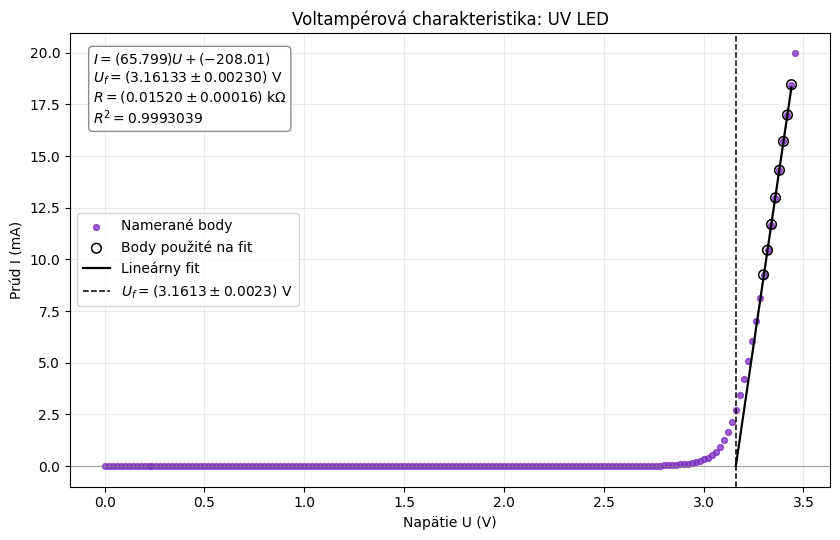

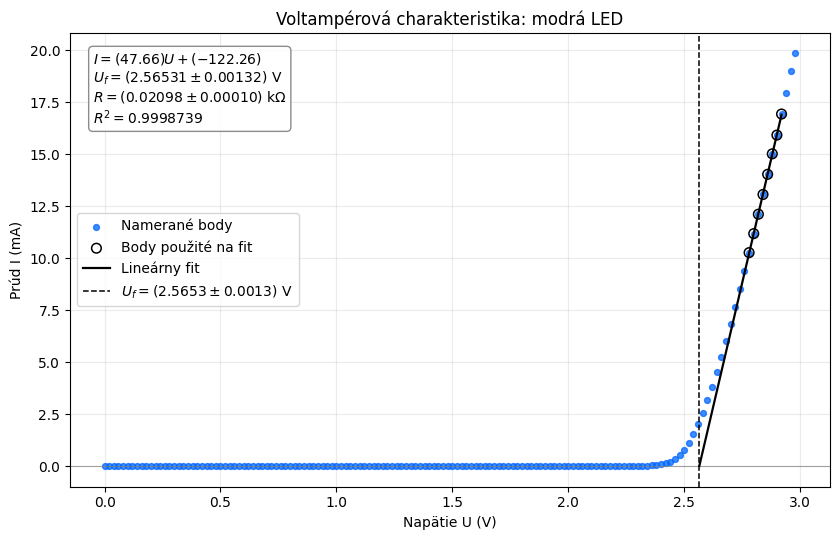

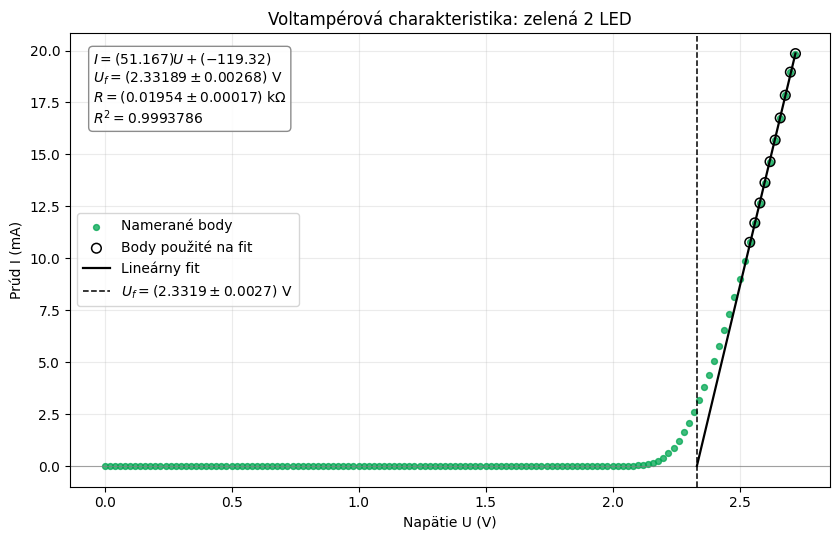

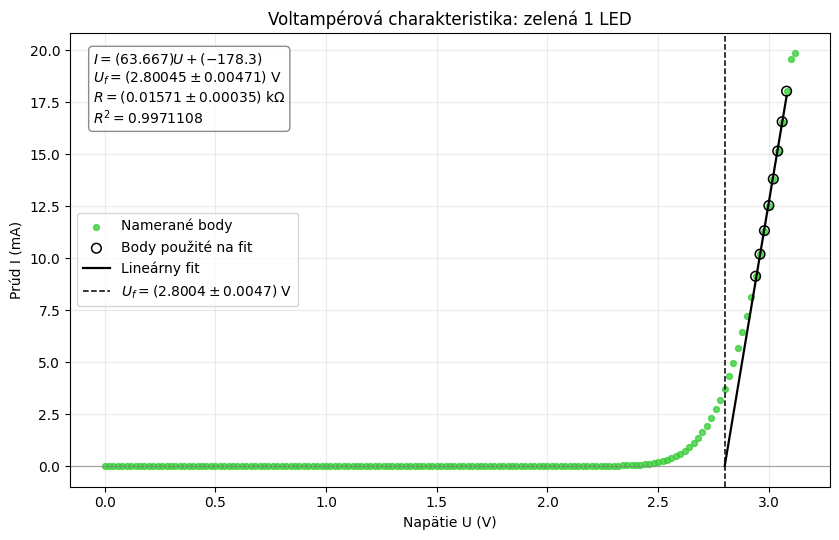

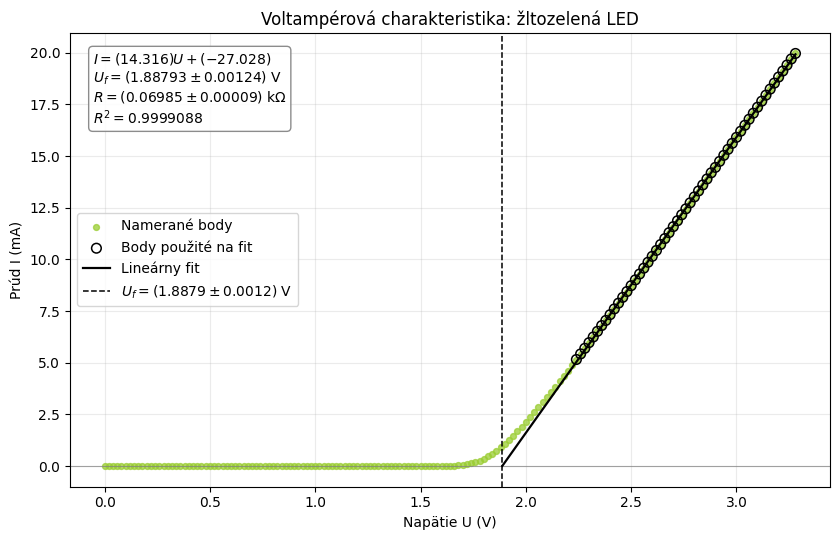

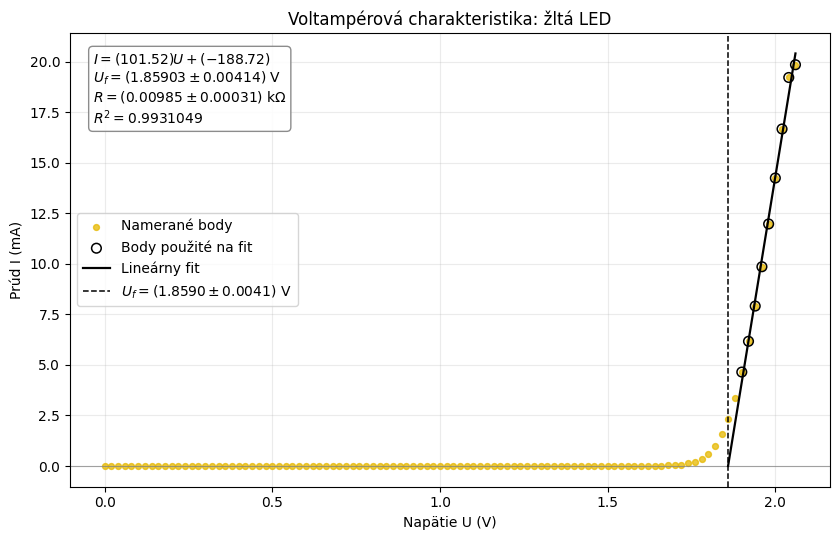

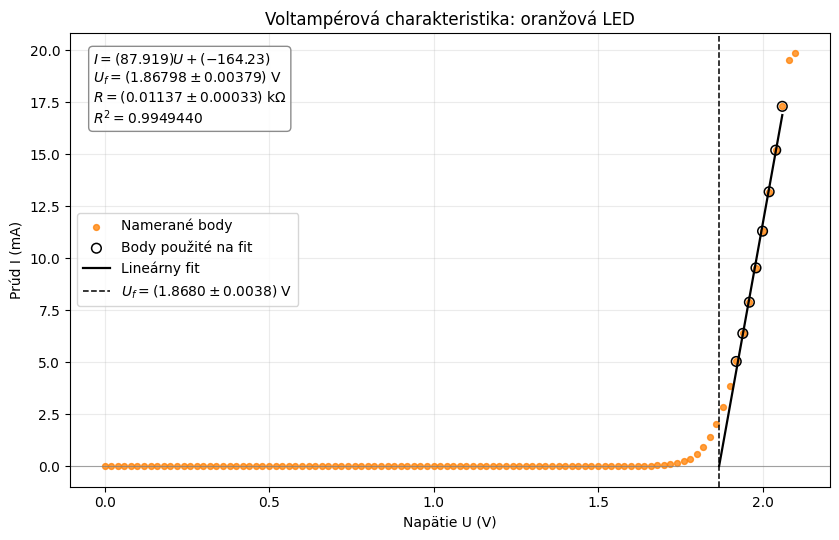

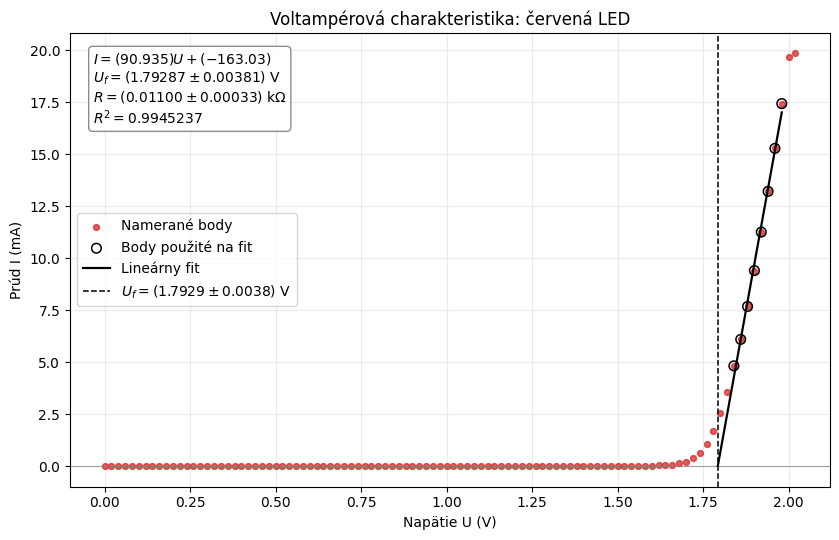

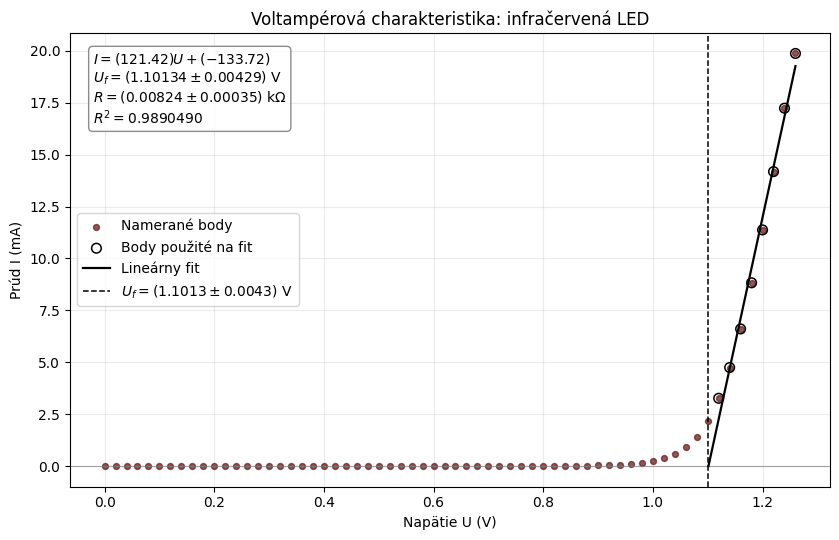

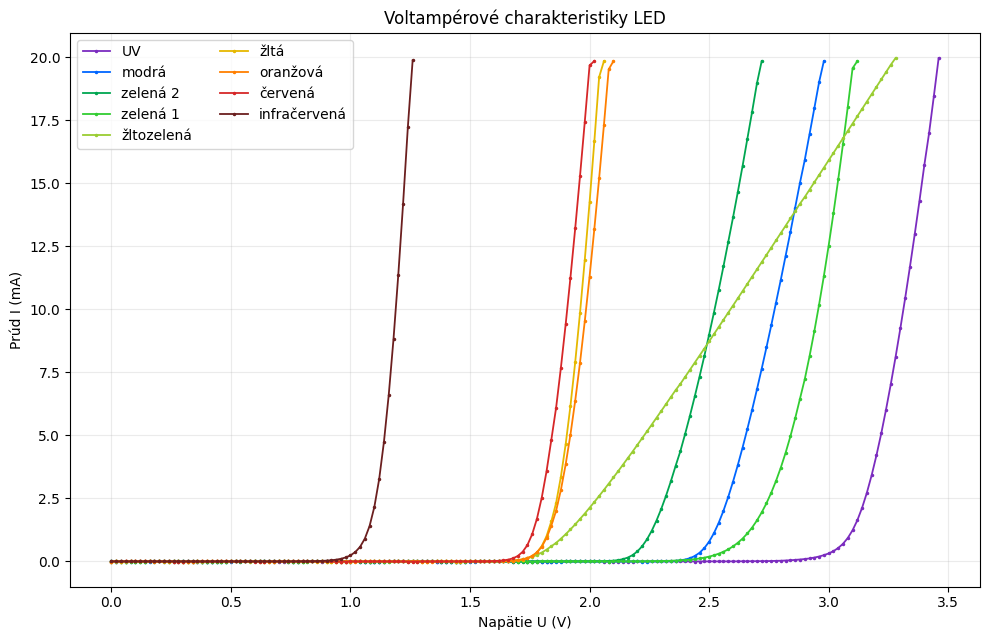

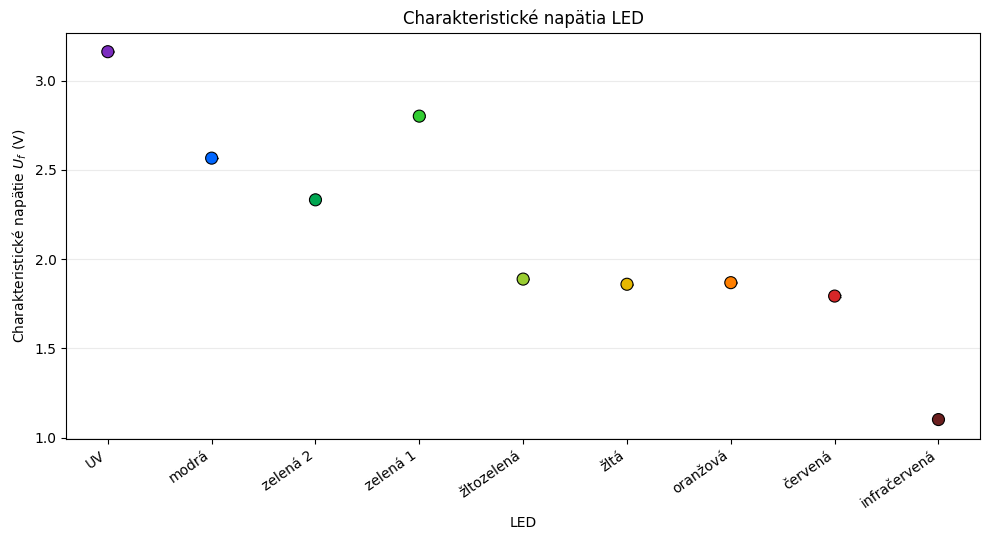


SPRACOVANIE DOKONČENÉ

Tabuľka výsledkov:
/home/adam/Documents/Physicsl-laboratory-main/FP4/LED_SPEKTRA/atmk/grafy_voltamper/vysledky_voltamper.csv

Grafy boli uložené do:
/home/adam/Documents/Physicsl-laboratory-main/FP4/LED_SPEKTRA/atmk/grafy_voltamper

Dôležité: V zobrazených grafoch skontroluj čierne krúžky. Čierne krúžky označujú body použité na lineárny fit. Mali by ležať v približne priamej časti voltampérovej charakteristiky pri vyšších prúdoch.


In [6]:
# ============================================================
# SPRACOVANIE VOLTAMPEROVYCH CHARAKTERISTIK LED
# Verzia urcena pre Jupyter Notebook (.ipynb)
# ============================================================

from pathlib import Path
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. NASTAVENIA
# ============================================================

# Ak je notebook ulozeny priamo v priecinku "atmk",
# kde sa nachadzaju aj .dat subory, nechaj Path.cwd().
DATA_DIR = Path.cwd()

# Ak notebook nie je v priecinku atmk, pouzi namiesto toho:
#
# DATA_DIR = (
#     Path.home()
#     / "Documents"
#     / "Physics-laboratory-main"
#     / "FP4"
#     / "LED_SPEKTRA"
#     / "atmk"
# )

# Priecinok na ulozenie grafov a tabulky vysledkov.
OUTPUT_DIR = DATA_DIR / "grafy_voltamper"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Nazvy suborov presne podla priecinka.
LED_SUBORY = {
    "UV": "LEDUV.dat",
    "modrá": "LEDBLUE.dat",
    "zelená 2": "LEDGREEN2.dat",
    "zelená 1": "LEDGREEN1.dat",
    "žltozelená": "LEDYELGREEN.dat",
    "žltá": "LEDYELLOW.dat",
    "oranžová": "LEDORANGE.dat",
    "červená": "LEDRED.dat",
    "infračervená": "LEDIR.dat",
}

# Farby pouzite v grafoch.
FARBY = {
    "UV": "#7b2cbf",
    "modrá": "#0066ff",
    "zelená 2": "#00a651",
    "zelená 1": "#32cd32",
    "žltozelená": "#9acd32",
    "žltá": "#e6b800",
    "oranžová": "#ff7f00",
    "červená": "#d62728",
    "infračervená": "#6b1f1f",
}

# Minimalny pocet bodov pouzitych na linearny fit.
MIN_POCET_BODOV = 8

# Ak automaticky fit nevyberie dobru oblast, mozes tu zadat
# interval prudu v mA rucne pre konkretnu LED.
#
# Napriklad:
#
# RUCNE_INTERVALY = {
#     "UV": (5.0, 18.0),
#     "modrá": (5.0, 18.0),
#     "červená": (4.0, 17.0),
# }
#
# Zatial nechaj prazdne:
RUCNE_INTERVALY = {
    "infračervená": (3.0, 20.0),
}


# ============================================================
# 2. FUNKCIA NA NACITANIE DAT
# ============================================================

def nacitaj_data(cesta):
    """
    Nacita .dat subor s dvoma stlpcami:

    1. napatie U vo voltoch,
    2. prud I v miliamperoch.

    Riadky zacinajuce znakom # sa ignoruju.
    """

    data = pd.read_csv(
        cesta,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["U_V", "I_mA"],
        usecols=[0, 1],
        engine="python",
    )

    # Prevod na cisla. Neplatne hodnoty sa zmenia na NaN.
    data["U_V"] = pd.to_numeric(data["U_V"], errors="coerce")
    data["I_mA"] = pd.to_numeric(data["I_mA"], errors="coerce")

    # Odstranenie neplatnych riadkov.
    data = data.dropna(subset=["U_V", "I_mA"])

    # Zoradenie podla napatia.
    data = data.sort_values("U_V").reset_index(drop=True)

    # Ak sa rovnake napatie vyskytuje viackrat,
    # prud sa spriemeruje.
    data = (
        data.groupby("U_V", as_index=False)["I_mA"]
        .mean()
        .sort_values("U_V")
        .reset_index(drop=True)
    )

    return data


# ============================================================
# 3. POMOCNA FUNKCIA NA VYPOCET R^2
# ============================================================

def vypocitaj_R2(U, I, a, b):
    """
    Vypocita koeficient determinacie R^2
    pre priamku I = a*U + b.
    """

    I_fit = a * U + b

    ss_res = np.sum((I - I_fit) ** 2)
    ss_tot = np.sum((I - np.mean(I)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


# ============================================================
# 4. AUTOMATICKY VYBER LINEARNEJ OBLASTI
# ============================================================

def vyber_linearnej_oblasti(
    data,
    nazov_led,
    min_pocet_bodov=MIN_POCET_BODOV,
):
    """
    Vyberie oblast pri vyssich kladnych prudoch,
    ktora je priblizne linearna.

    Skusaju sa rozne intervaly prudu vyjadrene ako cast
    maximalneho nameraneho prudu.

    Pre oblast vysokych prudov pouzivame aproximaciu:

        I = a*U + b

    Charakteristicke napatie potom urcime z I = 0:

        Uf = -b/a
    """

    kladne_data = data[data["I_mA"] > 0].copy()

    if len(kladne_data) < min_pocet_bodov:
        raise ValueError(
            f"V dátach je iba {len(kladne_data)} bodov "
            f"s kladným prúdom."
        )

    # Rucne zadany interval ma prednost.
    if nazov_led in RUCNE_INTERVALY:
        I_min, I_max = RUCNE_INTERVALY[nazov_led]

        fit_data = kladne_data[
            (kladne_data["I_mA"] >= I_min)
            & (kladne_data["I_mA"] <= I_max)
        ].copy()

        if len(fit_data) < min_pocet_bodov:
            raise ValueError(
                f"Ručný interval obsahuje iba {len(fit_data)} bodov."
            )

        sposob = f"ručný interval {I_min:.3g} až {I_max:.3g} mA"

        return fit_data, sposob

    I_max_celkovy = kladne_data["I_mA"].max()

    # Mozne hranice fitovanej oblasti.
    dolne_podiely = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
    horne_podiely = [0.80, 0.85, 0.90, 0.95, 1.00]

    najlepsi_vyber = None
    najlepsie_skore = -np.inf

    for dolny_podiel in dolne_podiely:
        for horny_podiel in horne_podiely:

            if dolny_podiel >= horny_podiel:
                continue

            I_min = dolny_podiel * I_max_celkovy
            I_max = horny_podiel * I_max_celkovy

            fit_data = kladne_data[
                (kladne_data["I_mA"] >= I_min)
                & (kladne_data["I_mA"] <= I_max)
            ].copy()

            if len(fit_data) < min_pocet_bodov:
                continue

            U = fit_data["U_V"].to_numpy()
            I = fit_data["I_mA"].to_numpy()

            a, b = np.polyfit(U, I, 1)

            # Smernica musi byt kladna.
            if a <= 0:
                continue

            R2 = vypocitaj_R2(U, I, a, b)

            if not np.isfinite(R2):
                continue

            Uf = -b / a

            # Uf by malo byt v rozumnom rozsahu meranych napati.
            if Uf < data["U_V"].min() or Uf > data["U_V"].max():
                continue

            # Skore uprednostni vysoke R^2.
            # Maly clen navyse mierne uprednostni vacsi pocet bodov.
            skore = R2 + 0.00001 * len(fit_data)

            if skore > najlepsie_skore:
                najlepsie_skore = skore

                najlepsi_vyber = {
                    "data": fit_data,
                    "dolny_podiel": dolny_podiel,
                    "horny_podiel": horny_podiel,
                    "R2": R2,
                }

    if najlepsi_vyber is None:
        raise ValueError(
            "Nepodarilo sa automaticky nájsť vhodnú lineárnu oblasť."
        )

    fit_data = najlepsi_vyber["data"]

    sposob = (
        f"automaticky: "
        f"{100 * najlepsi_vyber['dolny_podiel']:.0f} až "
        f"{100 * najlepsi_vyber['horny_podiel']:.0f} % z Imax"
    )

    return fit_data, sposob


# ============================================================
# 5. LINEARNY FIT A VYPOCET Uf
# ============================================================

def fit_voltamperovej_charakteristiky(fit_data):
    """
    Aproximuje vybranu oblast priamkou:

        I = a*U + b

    a ma jednotku mA/V.
    b ma jednotku mA.

    Charakteristicke napatie:

        Uf = -b/a

    Odpor linearnej oblasti:

        R = 1/a

    Pretoze a je v mA/V, hodnota 1/a vychadza v kiloohmoch.
    """

    U = fit_data["U_V"].to_numpy()
    I = fit_data["I_mA"].to_numpy()

    if len(U) < 3:
        raise ValueError("Na fit je príliš málo bodov.")

    # Linearny fit vratane kovariancnej matice.
    koeficienty, kovariancia = np.polyfit(
        U,
        I,
        deg=1,
        cov=True,
    )

    a, b = koeficienty

    if a <= 0:
        raise ValueError("Lineárny fit má nekladnú smernicu.")

    sigma_a = np.sqrt(kovariancia[0, 0])
    sigma_b = np.sqrt(kovariancia[1, 1])
    cov_ab = kovariancia[0, 1]

    # Charakteristicke napatie.
    Uf = -b / a

    # Propagacia neistoty pre Uf = -b/a.
    dUf_da = b / a**2
    dUf_db = -1 / a

    variancia_Uf = (
        dUf_da**2 * kovariancia[0, 0]
        + dUf_db**2 * kovariancia[1, 1]
        + 2 * dUf_da * dUf_db * cov_ab
    )

    sigma_Uf = np.sqrt(max(variancia_Uf, 0))

    # Odpor v kiloohmoch.
    R_kOhm = 1 / a
    sigma_R_kOhm = sigma_a / a**2

    R2 = vypocitaj_R2(U, I, a, b)

    return {
        "a_mA_na_V": a,
        "sigma_a_mA_na_V": sigma_a,
        "b_mA": b,
        "sigma_b_mA": sigma_b,
        "Uf_V": Uf,
        "sigma_Uf_V": sigma_Uf,
        "R_kOhm": R_kOhm,
        "sigma_R_kOhm": sigma_R_kOhm,
        "R2": R2,
    }


# ============================================================
# 6. FUNKCIA NA BEZPECNY NAZOV SUBORU
# ============================================================

def bezpecny_nazov(text):
    """
    Odstrani diakritiku a nahradi medzery podciarkovnikom.
    """

    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.replace(" ", "_")

    return text


# ============================================================
# 7. KONTROLA PRIECINKA A SUBOROV
# ============================================================

print("=" * 78)
print("SPRACOVANIE VOLTAMPEROVYCH CHARAKTERISTIK LED")
print("=" * 78)

print(f"\nPracovný priečinok:\n{DATA_DIR}")
print(f"\nVýstupný priečinok:\n{OUTPUT_DIR}")

print("\nKontrola dátových súborov:")

pocet_najdenych = 0

for nazov_led, nazov_suboru in LED_SUBORY.items():
    cesta = DATA_DIR / nazov_suboru

    if cesta.exists():
        print(f"  OK      {nazov_suboru}")
        pocet_najdenych += 1
    else:
        print(f"  CHÝBA   {nazov_suboru}")

print(f"\nNájdených súborov: {pocet_najdenych}/{len(LED_SUBORY)}")

if pocet_najdenych == 0:
    raise FileNotFoundError(
        "\nNenašiel sa ani jeden .dat súbor.\n"
        "Notebook pravdepodobne nie je uložený v priečinku atmk.\n"
        "Nastav DATA_DIR ručne v časti NASTAVENIA."
    )


# ============================================================
# 8. SPRACOVANIE VSETKYCH LED
# ============================================================

vsetky_data = {}
vsetky_fity = {}
vsetky_parametre = {}
vysledky = []

print("\n" + "=" * 78)
print("VÝPOČET CHARAKTERISTICKÝCH NAPÄTÍ")
print("=" * 78)

for nazov_led, nazov_suboru in LED_SUBORY.items():

    cesta = DATA_DIR / nazov_suboru

    if not cesta.exists():
        print(f"\n{nazov_led}: súbor {nazov_suboru} chýba, preskakujem.")
        continue

    try:
        data = nacitaj_data(cesta)

        if len(data) == 0:
            raise ValueError("Súbor neobsahuje použiteľné údaje.")

        fit_data, sposob = vyber_linearnej_oblasti(
            data,
            nazov_led,
        )

        fit = fit_voltamperovej_charakteristiky(fit_data)

        vsetky_data[nazov_led] = data
        vsetky_fity[nazov_led] = fit_data
        vsetky_parametre[nazov_led] = fit

        vysledky.append({
            "LED": nazov_led,
            "subor": nazov_suboru,
            "pocet_vsetkych_bodov": len(data),
            "pocet_bodov_fitu": len(fit_data),
            "U_fit_min_V": fit_data["U_V"].min(),
            "U_fit_max_V": fit_data["U_V"].max(),
            "I_fit_min_mA": fit_data["I_mA"].min(),
            "I_fit_max_mA": fit_data["I_mA"].max(),
            "sposob_vyberu": sposob,
            "Uf_V": fit["Uf_V"],
            "sigma_Uf_V": fit["sigma_Uf_V"],
            "R_kOhm": fit["R_kOhm"],
            "sigma_R_kOhm": fit["sigma_R_kOhm"],
            "R2": fit["R2"],
            "a_mA_na_V": fit["a_mA_na_V"],
            "sigma_a_mA_na_V": fit["sigma_a_mA_na_V"],
            "b_mA": fit["b_mA"],
            "sigma_b_mA": fit["sigma_b_mA"],
        })

        print(f"\n{nazov_led} LED")
        print(f"  Súbor: {nazov_suboru}")
        print(f"  Počet načítaných bodov: {len(data)}")
        print(f"  Počet bodov vo fite: {len(fit_data)}")
        print(f"  Výber oblasti: {sposob}")

        print(
            f"  Uf = {fit['Uf_V']:.6f} ± "
            f"{fit['sigma_Uf_V']:.6f} V"
        )

        print(
            f"  R = {fit['R_kOhm']:.6f} ± "
            f"{fit['sigma_R_kOhm']:.6f} kΩ"
        )

        print(f"  R² = {fit['R2']:.8f}")

    except Exception as chyba:
        print(f"\nCHYBA pri spracovaní {nazov_led} LED:")
        print(chyba)


if len(vysledky) == 0:
    raise RuntimeError(
        "Nepodarilo sa spracovať ani jednu LED charakteristiku."
    )

vysledky_df = pd.DataFrame(vysledky)


# ============================================================
# 9. VYPIS TABULKY VYSLEDKOV
# ============================================================

print("\n" + "=" * 78)
print("TABUĽKA VÝSLEDKOV")
print("=" * 78)

stlpce_na_vypis = [
    "LED",
    "Uf_V",
    "sigma_Uf_V",
    "R_kOhm",
    "sigma_R_kOhm",
    "R2",
    "pocet_bodov_fitu",
]

display(
    vysledky_df[stlpce_na_vypis].style.format({
        "Uf_V": "{:.6f}",
        "sigma_Uf_V": "{:.6f}",
        "R_kOhm": "{:.6f}",
        "sigma_R_kOhm": "{:.6f}",
        "R2": "{:.8f}",
    })
)


# ============================================================
# 10. SAMOSTATNE GRAFY JEDNOTLIVYCH LED
# ============================================================

print("\nVytváram samostatné grafy jednotlivých LED...")

for nazov_led in vsetky_data:

    data = vsetky_data[nazov_led]
    fit_data = vsetky_fity[nazov_led]
    fit = vsetky_parametre[nazov_led]

    farba = FARBY.get(nazov_led, "tab:blue")

    a = fit["a_mA_na_V"]
    b = fit["b_mA"]
    Uf = fit["Uf_V"]
    sigma_Uf = fit["sigma_Uf_V"]
    R_kOhm = fit["R_kOhm"]
    sigma_R_kOhm = fit["sigma_R_kOhm"]
    R2 = fit["R2"]

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    # Vsetky namerane body.
    ax.scatter(
        data["U_V"],
        data["I_mA"],
        s=18,
        color=farba,
        alpha=0.75,
        label="Namerané body",
        zorder=2,
    )

    # Body pouzite na fit.
    ax.scatter(
        fit_data["U_V"],
        fit_data["I_mA"],
        s=48,
        facecolors="none",
        edgecolors="black",
        linewidths=1.1,
        label="Body použité na fit",
        zorder=3,
    )

    # Fitovana priamka vratane extrapolacie k I = 0.
    U_priamka = np.linspace(
        Uf,
        fit_data["U_V"].max(),
        300,
    )

    I_priamka = a * U_priamka + b

    ax.plot(
        U_priamka,
        I_priamka,
        color="black",
        linewidth=1.6,
        label="Lineárny fit",
        zorder=4,
    )

    # Charakteristicke napatie.
    ax.axvline(
        Uf,
        color="black",
        linestyle="--",
        linewidth=1.1,
        label=rf"$U_f = ({Uf:.4f} \pm {sigma_Uf:.4f})$ V",
    )

    ax.axhline(
        0,
        color="gray",
        linewidth=0.8,
        alpha=0.7,
    )

    text_vysledku = (
        rf"$I = ({a:.5g})U + ({b:.5g})$"
        "\n"
        rf"$U_f = ({Uf:.5f} \pm {sigma_Uf:.5f})$ V"
        "\n"
        rf"$R = ({R_kOhm:.5f} \pm {sigma_R_kOhm:.5f})$ k$\Omega$"
        "\n"
        rf"$R^2 = {R2:.7f}$"
    )

    ax.text(
        0.03,
        0.96,
        text_vysledku,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=10,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "edgecolor": "gray",
            "alpha": 0.9,
        },
    )

    ax.set_title(
        f"Voltampérová charakteristika: {nazov_led} LED"
    )

    ax.set_xlabel("Napätie U (V)")
    ax.set_ylabel("Prúd I (mA)")

    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    fig.tight_layout()

    nazov_pre_subor = bezpecny_nazov(nazov_led)

    cesta_png = OUTPUT_DIR / f"VA_{nazov_pre_subor}.png"
    cesta_pdf = OUTPUT_DIR / f"VA_{nazov_pre_subor}.pdf"

    fig.savefig(
        cesta_png,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        cesta_pdf,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 11. SPOLOCNY GRAF VSETKYCH LED
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6.5))

for nazov_led, data in vsetky_data.items():

    ax.plot(
        data["U_V"],
        data["I_mA"],
        marker=".",
        markersize=3,
        linewidth=1.3,
        color=FARBY.get(nazov_led, None),
        label=nazov_led,
    )

ax.set_title("Voltampérové charakteristiky LED")
ax.set_xlabel("Napätie U (V)")
ax.set_ylabel("Prúd I (mA)")

ax.grid(True, alpha=0.25)
ax.legend(ncol=2)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "VA_vsetky_LED.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_DIR / "VA_vsetky_LED.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 12. GRAF CHARAKTERISTICKYCH NAPATI Uf
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(vysledky_df))

farby_bodov = [
    FARBY.get(nazov, "tab:blue")
    for nazov in vysledky_df["LED"]
]

ax.errorbar(
    x,
    vysledky_df["Uf_V"],
    yerr=vysledky_df["sigma_Uf_V"],
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
    zorder=2,
)

ax.scatter(
    x,
    vysledky_df["Uf_V"],
    c=farby_bodov,
    s=75,
    edgecolors="black",
    linewidths=0.8,
    zorder=3,
)

ax.set_xticks(x)

ax.set_xticklabels(
    vysledky_df["LED"],
    rotation=35,
    ha="right",
)

ax.set_title("Charakteristické napätia LED")
ax.set_xlabel("LED")
ax.set_ylabel(r"Charakteristické napätie $U_f$ (V)")

ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "charakteristicke_napatia_Uf.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_DIR / "charakteristicke_napatia_Uf.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 13. ULOZENIE TABULKY VYSLEDKOV
# ============================================================

cesta_csv = OUTPUT_DIR / "vysledky_voltamper.csv"

vysledky_df.to_csv(
    cesta_csv,
    index=False,
    encoding="utf-8-sig",
)

print("\n" + "=" * 78)
print("SPRACOVANIE DOKONČENÉ")
print("=" * 78)

print(f"\nTabuľka výsledkov:\n{cesta_csv}")
print(f"\nGrafy boli uložené do:\n{OUTPUT_DIR}")

print(
    "\nDôležité: V zobrazených grafoch skontroluj čierne krúžky. "
    "Čierne krúžky označujú body použité na lineárny fit. "
    "Mali by ležať v približne priamej časti voltampérovej "
    "charakteristiky pri vyšších prúdoch."
)

SPRACOVANIE SPEKTIER LED

Priečinok so spektrami:
/home/adam/Documents/Physicsl-laboratory-main/FP4/LED_SPEKTRA/MikusTabory

Použitý prepočet:
lambda [nm] = 1239.8 / E [eV]

Kontrola spektrálnych súborov:
  OK      UV12mA.dat
  OK      BLUE12mA.dat
  OK      GREEN2,12mA.dat
  OK      GREEN1,12mA.dat
  OK      YELGREEN12mA.dat
  OK      YELLOW12mA.dat
  OK      ORANGE12mA.dat
  OK      RED12mA.dat
  OK      IR12mA.dat

Nájdených súborov: 9/9

SPEKTRÁLNE MAXIMÁ

UV LED
  Súbor: UV12mA.dat
  Rozsah energie: 1.000 až 6.208 eV
  Rozsah vlnových dĺžok: 199.7 až 1239.7 nm
  Energia maxima: 3.33229 ± 0.00065 eV
  Vlnová dĺžka maxima: 372.06 ± 0.07 nm
  LED bude použitá na lineárny fit.

modrá LED
  Súbor: BLUE12mA.dat
  Rozsah energie: 1.000 až 6.208 eV
  Rozsah vlnových dĺžok: 199.7 až 1239.7 nm
  Energia maxima: 2.65427 ± 0.00065 eV
  Vlnová dĺžka maxima: 467.10 ± 0.11 nm
  LED bude použitá na lineárny fit.

zelená 2 LED
  Súbor: GREEN2,12mA.dat
  Rozsah energie: 1.000 až 6.208 eV
  Rozsah v

,LED,E_peak_eV,sigma_E_peak_eV,lambda_peak_nm,sigma_lambda_peak_nm,FWHM_nm,pouzit_na_fit
0,UV,3.33229,0.00065,372.06,0.07,21.26,True
1,modrá,2.65427,0.00065,467.10,0.11,25.17,True
2,zelená 2,2.37826,0.00065,521.30,0.14,40.73,True
3,zelená 1,2.38003,0.00065,520.92,0.14,34.92,True
4,žltozelená,2.19514,0.00065,564.79,0.17,30.11,True
5,žltá,2.09353,0.00065,592.21,0.18,21.37,True
6,oranžová,2.04993,0.00065,604.80,0.19,21.91,True
7,červená,1.98257,0.00065,625.35,0.20,22.43,True
8,infračervená,1.31760,0.00065,940.96,0.46,50.60,True



Vytváram grafy spektier v nanometroch...


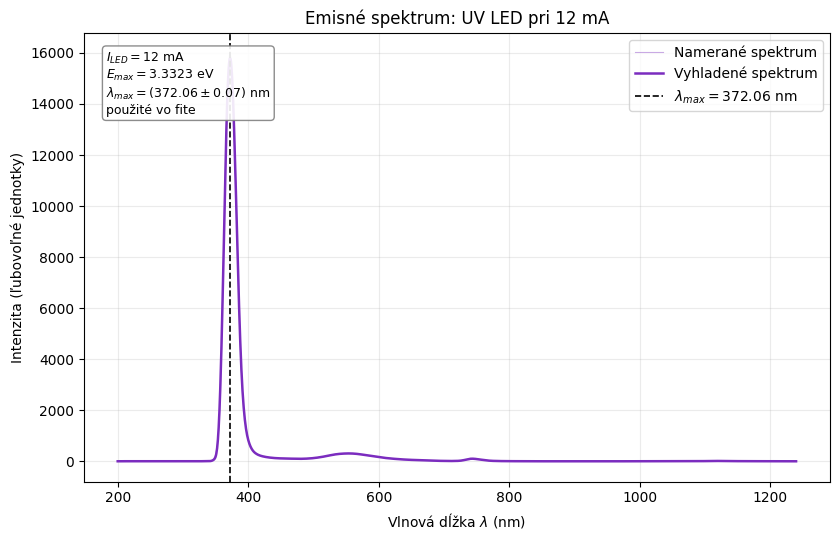

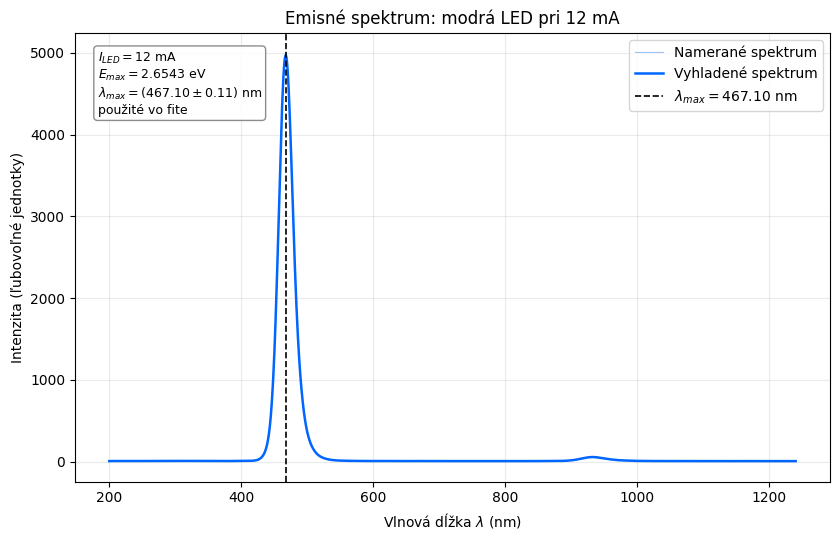

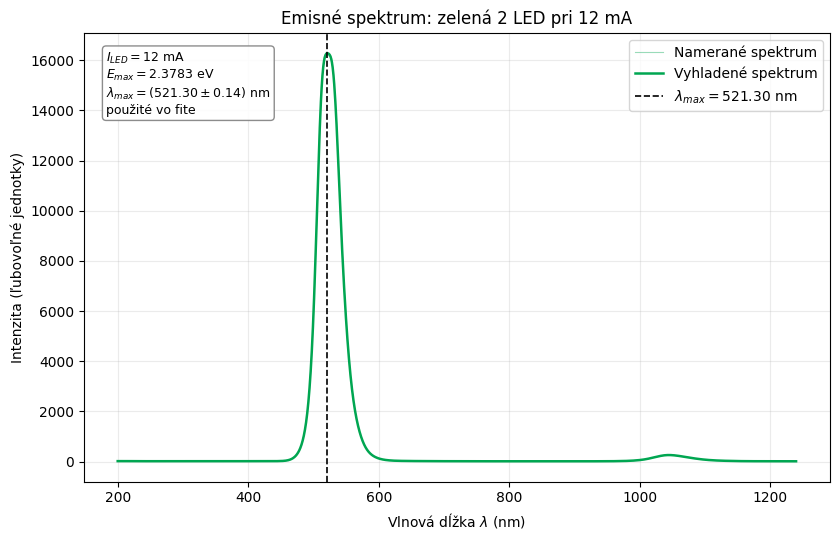

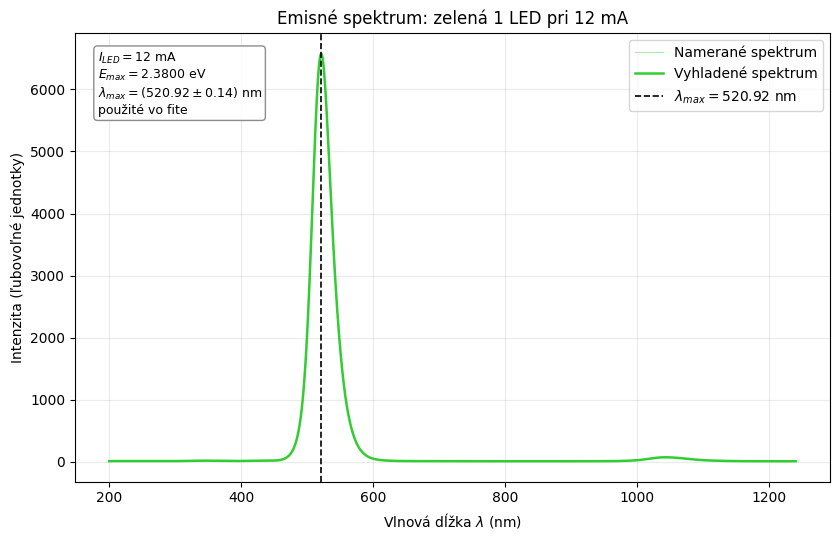

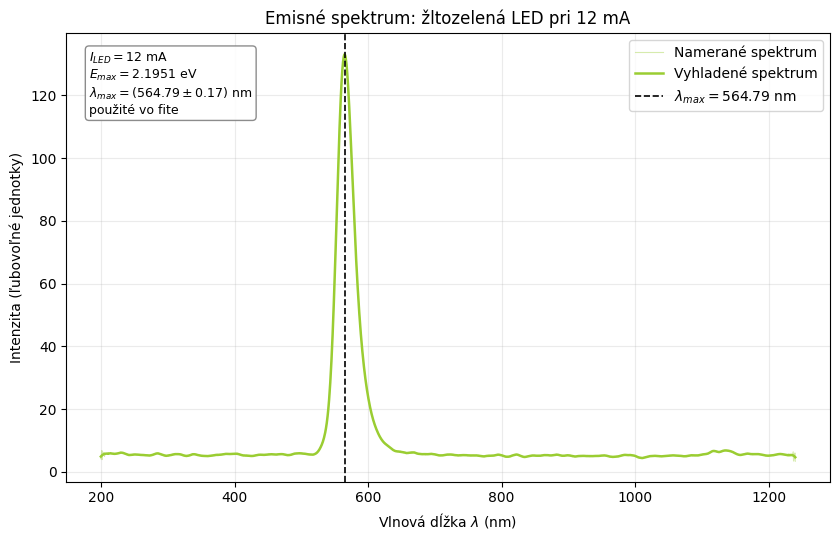

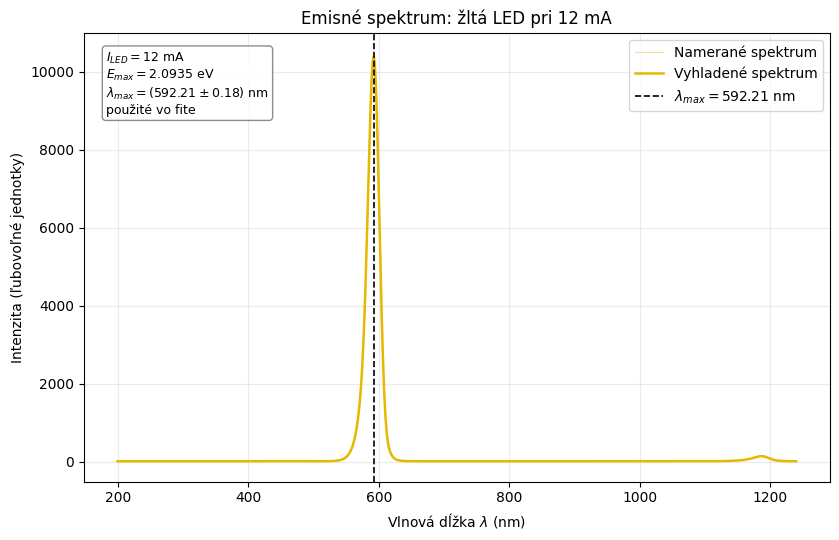

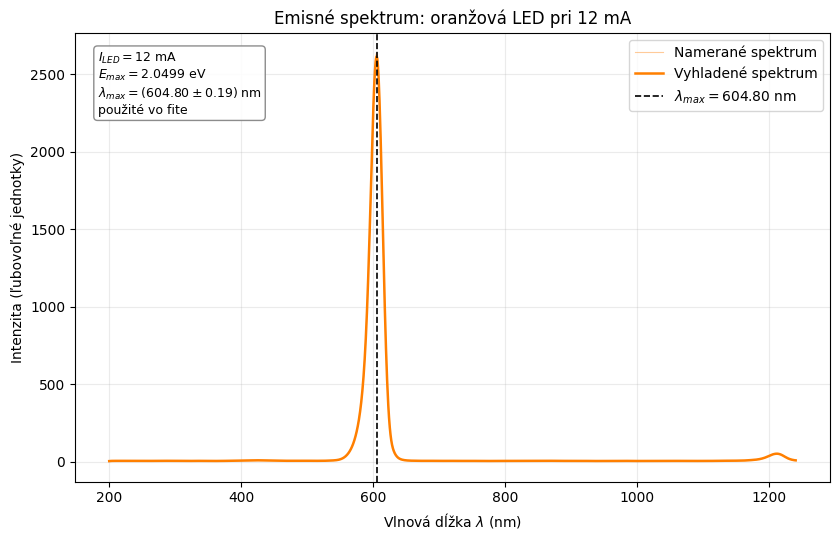

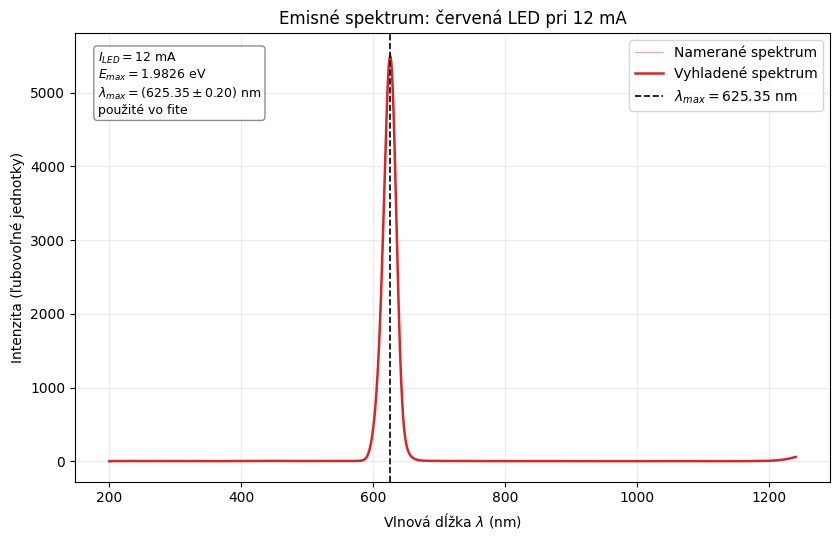

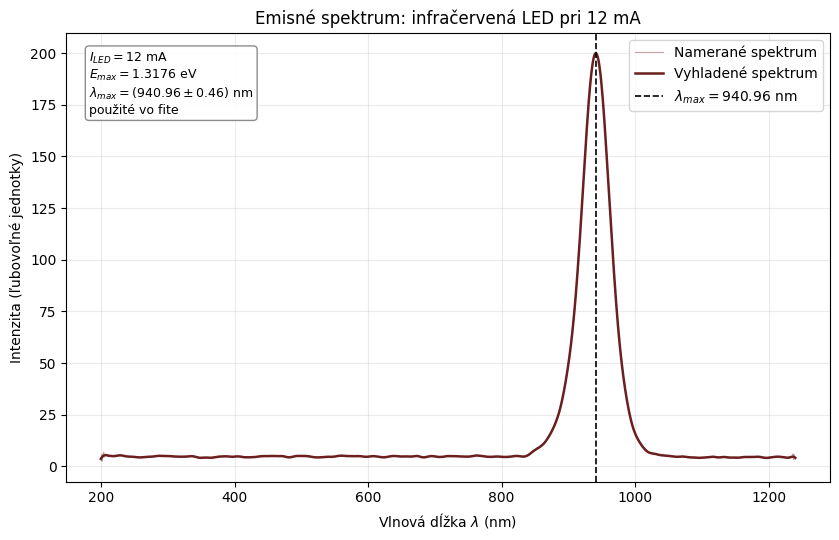

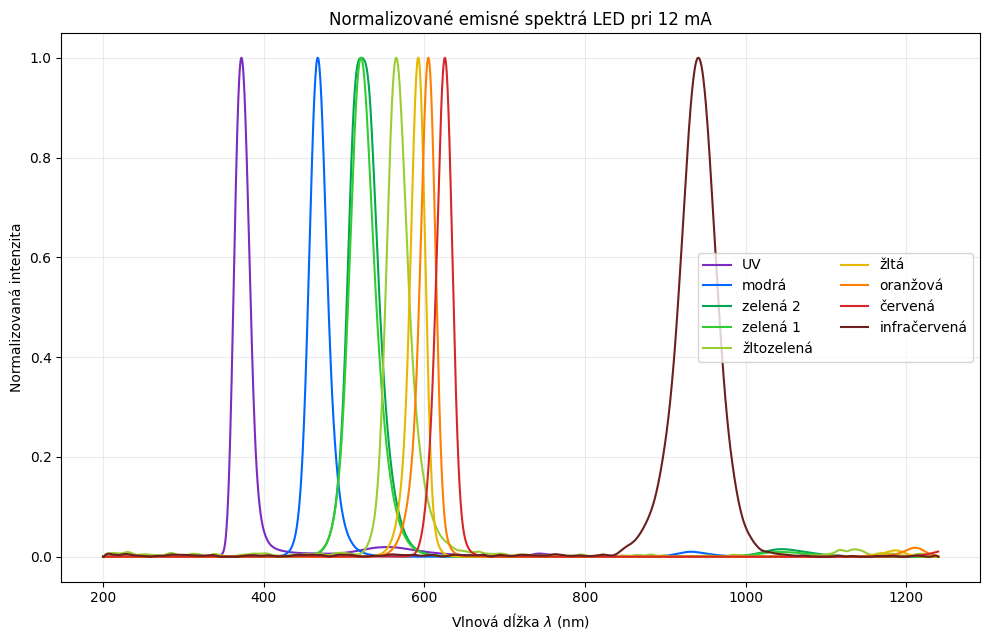


SPOJENÉ VÝSLEDKY


,LED,Uf_V,sigma_Uf_V,E_peak_eV,lambda_peak_nm,sigma_lambda_peak_nm,pouzit_na_fit
0,UV,3.161335,0.002302,3.33229,372.06,0.07,True
1,modrá,2.565308,0.001322,2.65427,467.10,0.11,True
2,zelená 2,2.331886,0.002677,2.37826,521.30,0.14,True
3,zelená 1,2.800448,0.004714,2.38003,520.92,0.14,True
4,žltozelená,1.887933,0.001236,2.19514,564.79,0.17,True
5,žltá,1.859029,0.004142,2.09353,592.21,0.18,True
6,oranžová,1.867975,0.003793,2.04993,604.80,0.19,True
7,červená,1.792875,0.003810,1.98257,625.35,0.20,True
8,infračervená,1.101345,0.004287,1.31760,940.96,0.46,True



VÝSLEDOK LINEÁRNEHO FITU

Použité LED:
  UV
  modrá
  zelená 2
  zelená 1
  žltozelená
  žltá
  oranžová
  červená
  infračervená

Smernica:
B = (1.37319381e-06 ± 1.45622463e-07) V·m

Priesečník:
A = (-0.435795 ± 0.289404) V

Koeficient determinácie:
R² = 0.86794003

Formálne vypočítaná Planckova konštanta:
h = (7.338740e-34 ± 7.782481e-35) J·s

Tabuľková Planckova konštanta:
h = 6.62607015e-34 J·s

Relatívna odchýlka:
10.76 %

POZOR: Vlnová dĺžka bola vypočítaná zo vzťahu lambda = 1239.8/E. Konštanta 1239.8 eV nm už obsahuje tabuľkovú hodnotu súčinu h*c, takže výsledná hodnota h nie je úplne nezávislým experimentálnym určením.


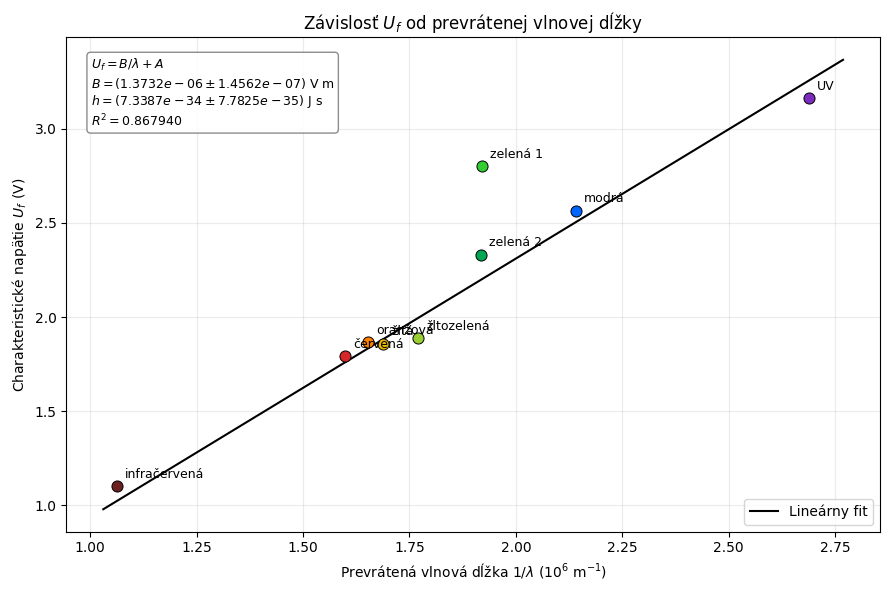

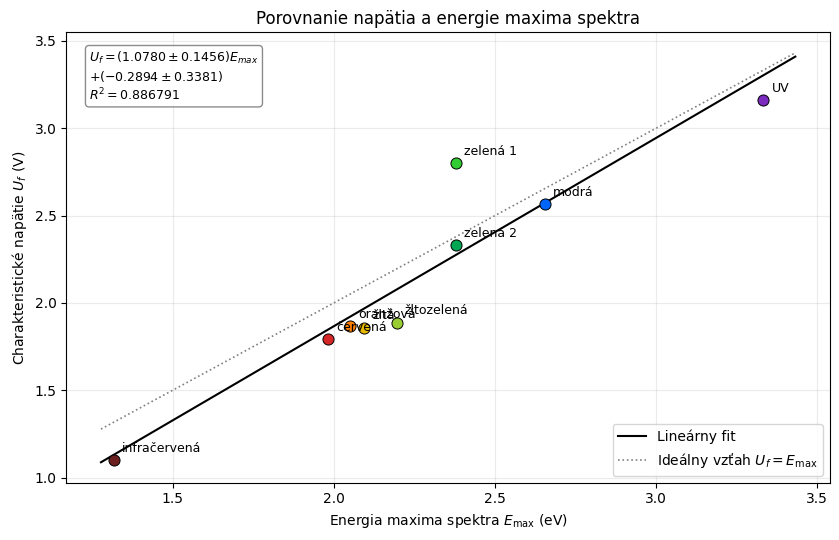


SPRACOVANIE DOKONČENÉ

Grafy a tabuľky boli uložené do:
/home/adam/Documents/Physicsl-laboratory-main/FP4/LED_SPEKTRA/atmk/grafy_voltamper/spektra_nm

Skontroluj grafy jednotlivých spektier. Vlnové dĺžky maxím by teraz mali približne zodpovedať farbám LED.


In [9]:
# ============================================================
# SPRACOVANIE SPEKTIER LED
# PREPOCET ENERGIE eV NA VLNOVU DLZKU nm
# A FORMALNY VYPOCET PLANCKOVEJ KONSTANTY
#
# Tento kod vloz do jednej novej bunky v Jupyter Notebooku.
#
# Pred spustenim musi byt spustena bunka s voltamperovymi
# charakteristikami, ktora vytvorila:
#
# DATA_DIR
# OUTPUT_DIR
# vysledky_df
# FARBY
# ============================================================

from pathlib import Path
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.signal import savgol_filter
except ImportError:
    raise ImportError(
        "Chýba knižnica scipy. Nainštaluj ju príkazom: pip install scipy"
    )


# ============================================================
# 1. KONTROLA PREDCHADZAJUCEJ BUNKY
# ============================================================

potrebne_premenne = [
    "DATA_DIR",
    "OUTPUT_DIR",
    "vysledky_df",
    "FARBY",
]

chybajuce_premenne = [
    nazov
    for nazov in potrebne_premenne
    if nazov not in globals()
]

if chybajuce_premenne:
    raise RuntimeError(
        "Najskôr spusti bunku s voltampérovými charakteristikami. "
        "Chýbajú premenné: "
        + ", ".join(chybajuce_premenne)
    )


# ============================================================
# 2. NASTAVENIA
# ============================================================

# Predpokladana struktura priecinkov:
#
# LED_SPEKTRA/
# ├── atmk/
# │   ├── notebook.ipynb
# │   └── voltamperove subory
# └── MikusTabory/
#     └── spektralne subory

SPECTRUM_DIR = DATA_DIR.parent / "MikusTabory"

SPECTRUM_OUTPUT_DIR = OUTPUT_DIR / "spektra_nm"
SPECTRUM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Nazvy spektralnych suborov
SPEKTRALNE_SUBORY = {
    "UV": "UV12mA.dat",
    "modrá": "BLUE12mA.dat",
    "zelená 2": "GREEN2,12mA.dat",
    "zelená 1": "GREEN1,12mA.dat",
    "žltozelená": "YELGREEN12mA.dat",
    "žltá": "YELLOW12mA.dat",
    "oranžová": "ORANGE12mA.dat",
    "červená": "RED12mA.dat",
    "infračervená": "IR12mA.dat",
}

MERACI_PRUD_mA = 12.0


# Prepocitavaci vztah:
#
# lambda [nm] = HC [eV nm] / E [eV]

HC_eV_nm = 1239.8


# Fyzikalne konstanty
ELEMENTARNY_NABOJ_C = 1.602176634e-19
RYCHLOST_SVETLA_m_s = 299792458.0
PLANCKOVA_KONSTANTA_TABULKOVA_Js = 6.62607015e-34


# Nastavenie vyhladenia
POZADOVANE_OKNO_VYHLADENIA = 31
STUPEN_POLYNOMU = 3


# Pocet bodov od kraja dat, ktore sa povazuju za okraj.
# Ak maximum lezi prilis blizko okraja, LED sa automaticky
# vyluci z fitu Planckovej konstanty.
POCET_OKRAJOVYCH_BODOV = 8


# Sem mozes doplnit LED, ktore chces rucne vyradit z fitu.
#
# Priklad:
# RUCNE_VYLUCENE_LED = {"UV", "infračervená"}

RUCNE_VYLUCENE_LED = set()


# Ak program vyberie nespravny pik, mozes obmedzit interval
# hladania maxima v nm.
#
# Priklad:
#
# RUCNE_INTERVALY_MAXIMA_NM = {
#     "UV": (300, 420),
#     "modrá": (400, 500),
#     "zelená 2": (480, 570),
#     "zelená 1": (480, 570),
#     "žltozelená": (520, 590),
#     "žltá": (550, 610),
#     "oranžová": (570, 650),
#     "červená": (600, 750),
#     "infračervená": (700, 1000),
# }

RUCNE_INTERVALY_MAXIMA_NM = {}


# ============================================================
# 3. POMOCNE FUNKCIE
# ============================================================

def bezpecny_nazov(text):
    """
    Odstrani diakritiku a nahradi medzery podciarkovnikmi.
    """

    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.replace(" ", "_")

    return text


def nacitaj_spektrum(cesta):
    """
    Nacita spektralny subor.

    Prvy stlpec:
        energia fotonov v eV

    Druhy stlpec:
        intenzita v lubovolnych jednotkach

    Vlnova dlzka sa vypocita:

        lambda [nm] = 1239.8 / E [eV]
    """

    riadky = cesta.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    energie = []
    intenzity = []

    for riadok in riadky:

        riadok = riadok.strip()

        if not riadok:
            continue

        if riadok.startswith("#") or riadok.startswith("%"):
            continue

        casti = riadok.split()

        if len(casti) < 2:
            continue

        try:
            energia_eV = float(
                casti[0].replace(",", ".")
            )

            intenzita = float(
                casti[1].replace(",", ".")
            )

        except ValueError:
            continue

        if (
            np.isfinite(energia_eV)
            and np.isfinite(intenzita)
            and energia_eV > 0
        ):
            energie.append(energia_eV)
            intenzity.append(intenzita)

    if len(energie) == 0:
        raise ValueError(
            "V súbore sa nenašli použiteľné číselné údaje."
        )

    data = pd.DataFrame({
        "energia_eV": energie,
        "intenzita": intenzity,
    })

    # Zoradenie podla energie je vhodne na vyhladenie dat
    data = (
        data.groupby("energia_eV", as_index=False)["intenzita"]
        .mean()
        .sort_values("energia_eV")
        .reset_index(drop=True)
    )

    # Prepocet z energie na vlnovu dlzku
    data["lambda_nm"] = (
        HC_eV_nm / data["energia_eV"]
    )

    return data


def urci_okno_vyhladenia(pocet_bodov):
    """
    Urci neparnu dlzku okna Savitzky-Golayovho filtra.
    """

    okno = min(
        POZADOVANE_OKNO_VYHLADENIA,
        pocet_bodov,
    )

    if okno % 2 == 0:
        okno -= 1

    minimalne_okno = STUPEN_POLYNOMU + 2

    if minimalne_okno % 2 == 0:
        minimalne_okno += 1

    if okno < minimalne_okno:
        return None

    return okno


def vyhlad_spektrum(data):
    """
    Vyhladi intenzitu na energetickej osi.
    """

    intenzita = data["intenzita"].to_numpy()

    okno = urci_okno_vyhladenia(len(data))

    if okno is None:
        return intenzita.copy(), None

    intenzita_vyhladena = savgol_filter(
        intenzita,
        window_length=okno,
        polyorder=STUPEN_POLYNOMU,
        mode="interp",
    )

    return intenzita_vyhladena, okno


def spresni_energiu_maxima(
    energia_eV,
    intenzita,
    index_maxima,
):
    """
    Spresni energiu maxima parabolickym fitom
    bodov v okoli najvacsieho bodu.
    """

    zaciatok = max(0, index_maxima - 3)
    koniec = min(
        len(energia_eV),
        index_maxima + 4,
    )

    E_okolie = energia_eV[zaciatok:koniec]
    I_okolie = intenzita[zaciatok:koniec]

    if len(E_okolie) < 3:
        return (
            energia_eV[index_maxima],
            intenzita[index_maxima],
        )

    try:
        koeficienty = np.polyfit(
            E_okolie,
            I_okolie,
            deg=2,
        )

        a, b, c = koeficienty

        # Maximum paraboly existuje iba pri a < 0
        if a >= 0:
            return (
                energia_eV[index_maxima],
                intenzita[index_maxima],
            )

        E_max_fit = -b / (2 * a)

        if (
            E_max_fit < E_okolie.min()
            or E_max_fit > E_okolie.max()
        ):
            return (
                energia_eV[index_maxima],
                intenzita[index_maxima],
            )

        I_max_fit = (
            a * E_max_fit**2
            + b * E_max_fit
            + c
        )

        return E_max_fit, I_max_fit

    except Exception:
        return (
            energia_eV[index_maxima],
            intenzita[index_maxima],
        )


def analyzuj_spektrum(data, nazov_led):
    """
    Vyhladi spektrum, najde emisne maximum a prepocita
    energiu maxima na vlnovu dlzku v nm.
    """

    energia_eV = data["energia_eV"].to_numpy()
    lambda_nm = data["lambda_nm"].to_numpy()
    intenzita = data["intenzita"].to_numpy()

    intenzita_vyhladena, okno = vyhlad_spektrum(data)

    # Odhad pozadia z 10 % najnizsich hodnot
    pocet_pozadia = max(
        3,
        int(0.10 * len(intenzita_vyhladena)),
    )

    pozadie = np.median(
        np.sort(intenzita_vyhladena)[:pocet_pozadia]
    )

    intenzita_bez_pozadia = (
        intenzita_vyhladena - pozadie
    )

    # Volitelny interval hladania maxima v nm
    if nazov_led in RUCNE_INTERVALY_MAXIMA_NM:

        lambda_min, lambda_max = (
            RUCNE_INTERVALY_MAXIMA_NM[nazov_led]
        )

        maska = (
            (lambda_nm >= lambda_min)
            & (lambda_nm <= lambda_max)
        )

        if np.sum(maska) < 5:
            raise ValueError(
                f"Ručný interval {lambda_min} až "
                f"{lambda_max} nm obsahuje príliš málo bodov."
            )

    else:
        maska = np.ones(
            len(data),
            dtype=bool,
        )

    povodne_indexy = np.where(maska)[0]

    intenzita_hladanie = (
        intenzita_bez_pozadia[maska]
    )

    lokalny_index_maxima = int(
        np.argmax(intenzita_hladanie)
    )

    index_maxima = int(
        povodne_indexy[lokalny_index_maxima]
    )

    E_max_bod_eV = energia_eV[index_maxima]

    E_max_fit_eV, I_max_fit = spresni_energiu_maxima(
        energia_eV,
        intenzita_vyhladena,
        index_maxima,
    )

    # Prepocet energie maxima na vlnovu dlzku
    lambda_max_nm = HC_eV_nm / E_max_fit_eV

    # Odhad neistoty energie ako polovica kroku energetickej osi
    if len(energia_eV) > 1:

        krok_E_eV = abs(
            np.median(np.diff(energia_eV))
        )

        sigma_E_eV = krok_E_eV / 2

    else:
        krok_E_eV = np.nan
        sigma_E_eV = np.nan

    # Propagacia neistoty:
    #
    # lambda = HC / E
    #
    # sigma_lambda = HC * sigma_E / E^2

    if np.isfinite(sigma_E_eV):

        sigma_lambda_nm = (
            HC_eV_nm
            * sigma_E_eV
            / E_max_fit_eV**2
        )

    else:
        sigma_lambda_nm = np.nan

    # Kontrola maxima na okraji energetickych dat
    maximum_na_lavom_okraji = (
        index_maxima < POCET_OKRAJOVYCH_BODOV
    )

    maximum_na_pravom_okraji = (
        index_maxima
        >= len(data) - POCET_OKRAJOVYCH_BODOV
    )

    maximum_na_okraji = (
        maximum_na_lavom_okraji
        or maximum_na_pravom_okraji
    )

    # FWHM najskor vypocitame na energetickej osi
    maximum_nad_pozadim = (
        intenzita_bez_pozadia[index_maxima]
    )

    polovica_maxima = maximum_nad_pozadim / 2

    indexy_nad_polovicou = np.where(
        intenzita_bez_pozadia >= polovica_maxima
    )[0]

    if len(indexy_nad_polovicou) >= 2:

        E1 = energia_eV[indexy_nad_polovicou[0]]
        E2 = energia_eV[indexy_nad_polovicou[-1]]

        FWHM_eV = abs(E2 - E1)

        lambda1_nm = HC_eV_nm / E1
        lambda2_nm = HC_eV_nm / E2

        FWHM_nm = abs(lambda2_nm - lambda1_nm)

    else:
        FWHM_eV = np.nan
        FWHM_nm = np.nan

    return {
        "energia_eV": energia_eV,
        "lambda_nm": lambda_nm,
        "intenzita": intenzita,
        "intenzita_vyhladena": intenzita_vyhladena,
        "intenzita_bez_pozadia": intenzita_bez_pozadia,
        "pozadie": pozadie,
        "okno_vyhladenia": okno,
        "index_maxima": index_maxima,
        "E_peak_eV": E_max_fit_eV,
        "sigma_E_peak_eV": sigma_E_eV,
        "lambda_peak_nm": lambda_max_nm,
        "sigma_lambda_peak_nm": sigma_lambda_nm,
        "I_peak": I_max_fit,
        "FWHM_eV": FWHM_eV,
        "FWHM_nm": FWHM_nm,
        "maximum_na_okraji": maximum_na_okraji,
    }


# ============================================================
# 4. KONTROLA SUBOROV
# ============================================================

print("=" * 78)
print("SPRACOVANIE SPEKTIER LED")
print("=" * 78)

print(f"\nPriečinok so spektrami:\n{SPECTRUM_DIR}")

print(
    "\nPoužitý prepočet:\n"
    "lambda [nm] = 1239.8 / E [eV]"
)

if not SPECTRUM_DIR.exists():
    raise FileNotFoundError(
        f"Priečinok so spektrami neexistuje:\n"
        f"{SPECTRUM_DIR}\n\n"
        "Skontroluj premennú SPECTRUM_DIR."
    )

print("\nKontrola spektrálnych súborov:")

pocet_najdenych = 0

for nazov_led, nazov_suboru in SPEKTRALNE_SUBORY.items():

    cesta = SPECTRUM_DIR / nazov_suboru

    if cesta.exists():
        print(f"  OK      {nazov_suboru}")
        pocet_najdenych += 1
    else:
        print(f"  CHÝBA   {nazov_suboru}")

print(
    f"\nNájdených súborov: "
    f"{pocet_najdenych}/{len(SPEKTRALNE_SUBORY)}"
)

if pocet_najdenych == 0:
    raise FileNotFoundError(
        "Nenašiel sa ani jeden spektrálny súbor."
    )


# ============================================================
# 5. SPRACOVANIE SPEKTIER
# ============================================================

spektra_data = {}
spektra_analyza = {}
vysledky_spektier = []

print("\n" + "=" * 78)
print("SPEKTRÁLNE MAXIMÁ")
print("=" * 78)

for nazov_led, nazov_suboru in SPEKTRALNE_SUBORY.items():

    cesta = SPECTRUM_DIR / nazov_suboru

    if not cesta.exists():
        continue

    try:
        data = nacitaj_spektrum(cesta)
        analyza = analyzuj_spektrum(
            data,
            nazov_led,
        )

        spektra_data[nazov_led] = data
        spektra_analyza[nazov_led] = analyza

        pouzit_na_fit = (
            not analyza["maximum_na_okraji"]
            and nazov_led not in RUCNE_VYLUCENE_LED
        )

        dovod_vylucenia = ""

        if analyza["maximum_na_okraji"]:
            dovod_vylucenia = (
                "maximum leží na okraji meracieho rozsahu"
            )

        if nazov_led in RUCNE_VYLUCENE_LED:
            dovod_vylucenia = "LED bola ručne vylúčená"

        vysledky_spektier.append({
            "LED": nazov_led,
            "subor_spektra": nazov_suboru,
            "prud_mA": MERACI_PRUD_mA,
            "pocet_bodov": len(data),
            "E_min_eV": data["energia_eV"].min(),
            "E_max_eV": data["energia_eV"].max(),
            "lambda_min_nm": data["lambda_nm"].min(),
            "lambda_max_nm": data["lambda_nm"].max(),
            "E_peak_eV": analyza["E_peak_eV"],
            "sigma_E_peak_eV": analyza["sigma_E_peak_eV"],
            "lambda_peak_nm": analyza["lambda_peak_nm"],
            "sigma_lambda_peak_nm": analyza["sigma_lambda_peak_nm"],
            "FWHM_eV": analyza["FWHM_eV"],
            "FWHM_nm": analyza["FWHM_nm"],
            "maximum_na_okraji": analyza["maximum_na_okraji"],
            "pouzit_na_fit": pouzit_na_fit,
            "dovod_vylucenia": dovod_vylucenia,
        })

        print(f"\n{nazov_led} LED")
        print(f"  Súbor: {nazov_suboru}")

        print(
            f"  Rozsah energie: "
            f"{data['energia_eV'].min():.3f} až "
            f"{data['energia_eV'].max():.3f} eV"
        )

        print(
            f"  Rozsah vlnových dĺžok: "
            f"{data['lambda_nm'].min():.1f} až "
            f"{data['lambda_nm'].max():.1f} nm"
        )

        print(
            f"  Energia maxima: "
            f"{analyza['E_peak_eV']:.5f} ± "
            f"{analyza['sigma_E_peak_eV']:.5f} eV"
        )

        print(
            f"  Vlnová dĺžka maxima: "
            f"{analyza['lambda_peak_nm']:.2f} ± "
            f"{analyza['sigma_lambda_peak_nm']:.2f} nm"
        )

        if analyza["maximum_na_okraji"]:
            print(
                "  UPOZORNENIE: Maximum je na okraji dát."
            )
            print(
                "  LED nebude použitá na lineárny fit."
            )

        elif nazov_led in RUCNE_VYLUCENE_LED:
            print(
                "  LED bola ručne vylúčená z fitu."
            )

        else:
            print(
                "  LED bude použitá na lineárny fit."
            )

    except Exception as chyba:
        print(f"\nCHYBA pri spracovaní {nazov_led}:")
        print(chyba)


if len(vysledky_spektier) == 0:
    raise RuntimeError(
        "Nepodarilo sa spracovať ani jedno spektrum."
    )

spektra_df = pd.DataFrame(vysledky_spektier)


# ============================================================
# 6. TABULKA SPEKTRALNYCH MAXIM
# ============================================================

print("\n" + "=" * 78)
print("TABUĽKA SPEKTRÁLNYCH MAXÍM")
print("=" * 78)

display(
    spektra_df[
        [
            "LED",
            "E_peak_eV",
            "sigma_E_peak_eV",
            "lambda_peak_nm",
            "sigma_lambda_peak_nm",
            "FWHM_nm",
            "pouzit_na_fit",
        ]
    ].style.format({
        "E_peak_eV": "{:.5f}",
        "sigma_E_peak_eV": "{:.5f}",
        "lambda_peak_nm": "{:.2f}",
        "sigma_lambda_peak_nm": "{:.2f}",
        "FWHM_nm": "{:.2f}",
    })
)


# ============================================================
# 7. GRAFY SPEKTIER V NANOMETROCH
# ============================================================

print("\nVytváram grafy spektier v nanometroch...")

for nazov_led, analyza in spektra_analyza.items():

    farba = FARBY.get(nazov_led, "tab:blue")

    lambda_nm = analyza["lambda_nm"]
    intenzita = analyza["intenzita"]
    intenzita_vyhladena = analyza["intenzita_vyhladena"]

    # Energia bola zoradena vzostupne.
    # Vlnova dlzka je preto zoradena zostupne.
    # Na vykreslenie ju zoradime vzostupne.

    zoradenie = np.argsort(lambda_nm)

    lambda_graf = lambda_nm[zoradenie]
    intenzita_graf = intenzita[zoradenie]
    intenzita_vyhladena_graf = (
        intenzita_vyhladena[zoradenie]
    )

    lambda_peak_nm = analyza["lambda_peak_nm"]
    sigma_lambda_nm = analyza["sigma_lambda_peak_nm"]

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    ax.plot(
        lambda_graf,
        intenzita_graf,
        color=farba,
        linewidth=0.8,
        alpha=0.4,
        label="Namerané spektrum",
    )

    ax.plot(
        lambda_graf,
        intenzita_vyhladena_graf,
        color=farba,
        linewidth=1.8,
        label="Vyhladené spektrum",
    )

    ax.axvline(
        lambda_peak_nm,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=(
            rf"$\lambda_{{max}} = "
            rf"{lambda_peak_nm:.2f}$ nm"
        ),
    )

    if analyza["maximum_na_okraji"]:
        stav = "maximum na okraji, nepoužité vo fite"
    elif nazov_led in RUCNE_VYLUCENE_LED:
        stav = "ručne vylúčené z fitu"
    else:
        stav = "použité vo fite"

    text_vysledku = (
        rf"$I_{{LED}} = {MERACI_PRUD_mA:.0f}$ mA"
        "\n"
        rf"$E_{{max}} = "
        rf"{analyza['E_peak_eV']:.4f}$ eV"
        "\n"
        rf"$\lambda_{{max}} = "
        rf"({lambda_peak_nm:.2f} \pm "
        rf"{sigma_lambda_nm:.2f})$ nm"
        "\n"
        f"{stav}"
    )

    ax.text(
        0.03,
        0.96,
        text_vysledku,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=9,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "edgecolor": "gray",
            "alpha": 0.9,
        },
    )

    ax.set_title(
        f"Emisné spektrum: {nazov_led} LED pri 12 mA"
    )

    ax.set_xlabel(
        r"Vlnová dĺžka $\lambda$ (nm)"
    )

    ax.set_ylabel(
        "Intenzita (ľubovoľné jednotky)"
    )

    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    fig.tight_layout()

    nazov_suboru = bezpecny_nazov(nazov_led)

    fig.savefig(
        SPECTRUM_OUTPUT_DIR / f"spektrum_{nazov_suboru}_nm.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        SPECTRUM_OUTPUT_DIR / f"spektrum_{nazov_suboru}_nm.pdf",
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 8. SPOLOCNY NORMALIZOVANY GRAF V NANOMETROCH
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6.5))

for nazov_led, analyza in spektra_analyza.items():

    lambda_nm = analyza["lambda_nm"]

    intenzita_normalizovana = (
        analyza["intenzita_vyhladena"]
        - analyza["pozadie"]
    )

    intenzita_normalizovana = np.clip(
        intenzita_normalizovana,
        0,
        None,
    )

    maximum = np.max(intenzita_normalizovana)

    if maximum > 0:
        intenzita_normalizovana /= maximum

    zoradenie = np.argsort(lambda_nm)

    ax.plot(
        lambda_nm[zoradenie],
        intenzita_normalizovana[zoradenie],
        linewidth=1.5,
        color=FARBY.get(nazov_led),
        label=nazov_led,
    )

ax.set_title(
    "Normalizované emisné spektrá LED pri 12 mA"
)

ax.set_xlabel(
    r"Vlnová dĺžka $\lambda$ (nm)"
)

ax.set_ylabel(
    "Normalizovaná intenzita"
)

ax.grid(True, alpha=0.25)
ax.legend(ncol=2)

fig.tight_layout()

fig.savefig(
    SPECTRUM_OUTPUT_DIR / "vsetky_spektra_nm.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    SPECTRUM_OUTPUT_DIR / "vsetky_spektra_nm.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 9. SPOJENIE SPEKTIER S VOLTAMPEROVYMI VYSLEDKAMI
# ============================================================

VA_vysledky = vysledky_df[
    [
        "LED",
        "Uf_V",
        "sigma_Uf_V",
    ]
].copy()

spojene_vysledky_df = pd.merge(
    VA_vysledky,
    spektra_df,
    on="LED",
    how="inner",
)

print("\n" + "=" * 78)
print("SPOJENÉ VÝSLEDKY")
print("=" * 78)

display(
    spojene_vysledky_df[
        [
            "LED",
            "Uf_V",
            "sigma_Uf_V",
            "E_peak_eV",
            "lambda_peak_nm",
            "sigma_lambda_peak_nm",
            "pouzit_na_fit",
        ]
    ].style.format({
        "Uf_V": "{:.6f}",
        "sigma_Uf_V": "{:.6f}",
        "E_peak_eV": "{:.5f}",
        "lambda_peak_nm": "{:.2f}",
        "sigma_lambda_peak_nm": "{:.2f}",
    })
)


# ============================================================
# 10. VYBER BODOV NA LINEARNY FIT
# ============================================================

planck_df = spojene_vysledky_df[
    spojene_vysledky_df["pouzit_na_fit"]
].copy()

if len(planck_df) < 3:
    raise RuntimeError(
        "Na lineárny fit zostali menej než tri LED. "
        "Skontroluj grafy spektier a automatické vylúčenie."
    )


# Prevod vlnovej dlzky z nm na metre
planck_df["lambda_m"] = (
    planck_df["lambda_peak_nm"] * 1e-9
)

planck_df["sigma_lambda_m"] = (
    planck_df["sigma_lambda_peak_nm"] * 1e-9
)


# Inverzna vlnova dlzka
planck_df["inv_lambda_m-1"] = (
    1 / planck_df["lambda_m"]
)


# Propagacia neistoty:
#
# x = 1/lambda
#
# sigma_x = sigma_lambda / lambda^2

planck_df["sigma_inv_lambda_m-1"] = (
    planck_df["sigma_lambda_m"]
    / planck_df["lambda_m"]**2
)


# ============================================================
# 11. LINEARNY FIT
#
# Uf = B * (1/lambda) + A
#
# B = h*c/e
#
# h = B*e/c
# ============================================================

x = planck_df["inv_lambda_m-1"].to_numpy()
y = planck_df["Uf_V"].to_numpy()
sigma_y = planck_df["sigma_Uf_V"].to_numpy()


# Oprava nulovych alebo neplatnych neistot
platne_neistoty = sigma_y[
    np.isfinite(sigma_y)
    & (sigma_y > 0)
]

if len(platne_neistoty) > 0:
    nahradna_neistota = np.median(platne_neistoty)
else:
    nahradna_neistota = 1.0

sigma_y = np.where(
    np.isfinite(sigma_y)
    & (sigma_y > 0),
    sigma_y,
    nahradna_neistota,
)


# Vazeny linearny fit
koeficienty, kovariancia = np.polyfit(
    x,
    y,
    deg=1,
    w=1 / sigma_y,
    cov=True,
)

B, A = koeficienty

sigma_B = np.sqrt(
    kovariancia[0, 0]
)

sigma_A = np.sqrt(
    kovariancia[1, 1]
)


# Koeficient determinacie
y_fit = B * x + A

ss_res = np.sum(
    (y - y_fit)**2
)

ss_tot = np.sum(
    (y - np.mean(y))**2
)

R2 = 1 - ss_res / ss_tot


# ============================================================
# 12. FORMALNY VYPOCET PLANCKOVEJ KONSTANTY
# ============================================================

h_experimentalne = (
    B
    * ELEMENTARNY_NABOJ_C
    / RYCHLOST_SVETLA_m_s
)

sigma_h = (
    sigma_B
    * ELEMENTARNY_NABOJ_C
    / RYCHLOST_SVETLA_m_s
)

relativna_odchylka_percent = (
    abs(
        h_experimentalne
        - PLANCKOVA_KONSTANTA_TABULKOVA_Js
    )
    / PLANCKOVA_KONSTANTA_TABULKOVA_Js
    * 100
)


print("\n" + "=" * 78)
print("VÝSLEDOK LINEÁRNEHO FITU")
print("=" * 78)

print("\nPoužité LED:")

for nazov_led in planck_df["LED"]:
    print(f"  {nazov_led}")

print(
    f"\nSmernica:\n"
    f"B = ({B:.8e} ± {sigma_B:.8e}) V·m"
)

print(
    f"\nPriesečník:\n"
    f"A = ({A:.6f} ± {sigma_A:.6f}) V"
)

print(
    f"\nKoeficient determinácie:\n"
    f"R² = {R2:.8f}"
)

print(
    f"\nFormálne vypočítaná Planckova konštanta:\n"
    f"h = ({h_experimentalne:.6e} ± "
    f"{sigma_h:.6e}) J·s"
)

print(
    f"\nTabuľková Planckova konštanta:\n"
    f"h = {PLANCKOVA_KONSTANTA_TABULKOVA_Js:.8e} J·s"
)

print(
    f"\nRelatívna odchýlka:\n"
    f"{relativna_odchylka_percent:.2f} %"
)

print(
    "\nPOZOR: Vlnová dĺžka bola vypočítaná zo vzťahu "
    "lambda = 1239.8/E. Konštanta 1239.8 eV nm už obsahuje "
    "tabuľkovú hodnotu súčinu h*c, takže výsledná hodnota h "
    "nie je úplne nezávislým experimentálnym určením."
)


# ============================================================
# 13. GRAF Uf PROTI 1/LAMBDA
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

for _, riadok in planck_df.iterrows():

    nazov_led = riadok["LED"]
    farba = FARBY.get(nazov_led, "tab:blue")

    x_bod = (
        riadok["inv_lambda_m-1"] / 1e6
    )

    x_chyba = (
        riadok["sigma_inv_lambda_m-1"] / 1e6
    )

    ax.errorbar(
        x_bod,
        riadok["Uf_V"],
        xerr=x_chyba,
        yerr=riadok["sigma_Uf_V"],
        fmt="o",
        color=farba,
        markeredgecolor="black",
        markeredgewidth=0.7,
        capsize=3,
        markersize=8,
    )

    ax.annotate(
        nazov_led,
        (
            x_bod,
            riadok["Uf_V"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )


x_priamka = np.linspace(
    x.min() * 0.97,
    x.max() * 1.03,
    300,
)

y_priamka = B * x_priamka + A

ax.plot(
    x_priamka / 1e6,
    y_priamka,
    color="black",
    linewidth=1.5,
    label="Lineárny fit",
)


text_vysledku = (
    rf"$U_f = B/\lambda + A$"
    "\n"
    rf"$B = ({B:.4e} \pm {sigma_B:.4e})$ V m"
    "\n"
    rf"$h = ({h_experimentalne:.4e} \pm "
    rf"{sigma_h:.4e})$ J s"
    "\n"
    rf"$R^2 = {R2:.6f}$"
)

ax.text(
    0.03,
    0.96,
    text_vysledku,
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=9,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.9,
    },
)

ax.set_title(
    r"Závislosť $U_f$ od prevrátenej vlnovej dĺžky"
)

ax.set_xlabel(
    r"Prevrátená vlnová dĺžka $1/\lambda$ "
    r"($10^6$ m$^{-1}$)"
)

ax.set_ylabel(
    r"Charakteristické napätie $U_f$ (V)"
)

ax.grid(True, alpha=0.25)
ax.legend(loc="best")

fig.tight_layout()

fig.savefig(
    SPECTRUM_OUTPUT_DIR / "Uf_proti_inverznej_lambda.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    SPECTRUM_OUTPUT_DIR / "Uf_proti_inverznej_lambda.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 14. GRAF Uf PROTI ENERGII MAXIMA
# ============================================================

E_peak = planck_df["E_peak_eV"].to_numpy()
Uf = planck_df["Uf_V"].to_numpy()

koeficienty_E, kovariancia_E = np.polyfit(
    E_peak,
    Uf,
    deg=1,
    cov=True,
)

smernica_E, priesecnik_E = koeficienty_E

sigma_smernica_E = np.sqrt(
    kovariancia_E[0, 0]
)

sigma_priesecnik_E = np.sqrt(
    kovariancia_E[1, 1]
)

Uf_fit_E = (
    smernica_E * E_peak
    + priesecnik_E
)

ss_res_E = np.sum(
    (Uf - Uf_fit_E)**2
)

ss_tot_E = np.sum(
    (Uf - np.mean(Uf))**2
)

R2_E = 1 - ss_res_E / ss_tot_E


fig, ax = plt.subplots(figsize=(8.5, 5.5))

for _, riadok in planck_df.iterrows():

    nazov_led = riadok["LED"]
    farba = FARBY.get(nazov_led, "tab:blue")

    ax.errorbar(
        riadok["E_peak_eV"],
        riadok["Uf_V"],
        xerr=riadok["sigma_E_peak_eV"],
        yerr=riadok["sigma_Uf_V"],
        fmt="o",
        color=farba,
        markeredgecolor="black",
        markeredgewidth=0.7,
        capsize=3,
        markersize=8,
    )

    ax.annotate(
        nazov_led,
        (
            riadok["E_peak_eV"],
            riadok["Uf_V"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )


E_priamka = np.linspace(
    E_peak.min() * 0.97,
    E_peak.max() * 1.03,
    300,
)

Uf_priamka_E = (
    smernica_E * E_priamka
    + priesecnik_E
)

ax.plot(
    E_priamka,
    Uf_priamka_E,
    color="black",
    linewidth=1.5,
    label="Lineárny fit",
)

ax.plot(
    E_priamka,
    E_priamka,
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label=r"Ideálny vzťah $U_f=E_{\mathrm{max}}$",
)

text_E = (
    rf"$U_f = ({smernica_E:.4f} \pm "
    rf"{sigma_smernica_E:.4f})E_{{max}}$"
    "\n"
    rf"$+ ({priesecnik_E:.4f} \pm "
    rf"{sigma_priesecnik_E:.4f})$"
    "\n"
    rf"$R^2 = {R2_E:.6f}$"
)

ax.text(
    0.03,
    0.96,
    text_E,
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=9,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.9,
    },
)

ax.set_title(
    "Porovnanie napätia a energie maxima spektra"
)

ax.set_xlabel(
    r"Energia maxima spektra $E_{\mathrm{max}}$ (eV)"
)

ax.set_ylabel(
    r"Charakteristické napätie $U_f$ (V)"
)

ax.grid(True, alpha=0.25)
ax.legend(loc="best")

fig.tight_layout()

fig.savefig(
    SPECTRUM_OUTPUT_DIR / "Uf_proti_energii_maxima.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    SPECTRUM_OUTPUT_DIR / "Uf_proti_energii_maxima.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 15. ULOZENIE VYSLEDKOV
# ============================================================

spektra_df.to_csv(
    SPECTRUM_OUTPUT_DIR / "vysledky_spektier_nm.csv",
    index=False,
    encoding="utf-8-sig",
)

spojene_vysledky_df.to_csv(
    SPECTRUM_OUTPUT_DIR / "spojene_vysledky_Uf_spektra.csv",
    index=False,
    encoding="utf-8-sig",
)

planck_df.to_csv(
    SPECTRUM_OUTPUT_DIR / "data_pre_fit_planckovej_konstanty.csv",
    index=False,
    encoding="utf-8-sig",
)


vysledok_h_df = pd.DataFrame({
    "velicina": [
        "B",
        "sigma_B",
        "A",
        "sigma_A",
        "R2",
        "h_formalne",
        "sigma_h",
        "h_tabulkove",
        "relativna_odchylka_percent",
        "HC_eV_nm",
    ],
    "hodnota": [
        B,
        sigma_B,
        A,
        sigma_A,
        R2,
        h_experimentalne,
        sigma_h,
        PLANCKOVA_KONSTANTA_TABULKOVA_Js,
        relativna_odchylka_percent,
        HC_eV_nm,
    ],
})

vysledok_h_df.to_csv(
    SPECTRUM_OUTPUT_DIR / "vysledok_planckova_konstanta.csv",
    index=False,
    encoding="utf-8-sig",
)


print("\n" + "=" * 78)
print("SPRACOVANIE DOKONČENÉ")
print("=" * 78)

print(
    f"\nGrafy a tabuľky boli uložené do:\n"
    f"{SPECTRUM_OUTPUT_DIR}"
)

print(
    "\nSkontroluj grafy jednotlivých spektier. "
    "Vlnové dĺžky maxím by teraz mali približne "
    "zodpovedať farbám LED."
)